In [131]:
!pip install gradio scikit-learn

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gradio as gr

In [133]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (3).csv


In [134]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [135]:
df = pd.read_csv('heart.csv')
df.shape

(1025, 14)

In [136]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [137]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [138]:
X = df.drop('target', axis=1)
y = df['target']

In [139]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [141]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [142]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [143]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7073 - loss: 0.6049 - val_accuracy: 0.7561 - val_loss: 0.5275
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8445 - loss: 0.4163 - val_accuracy: 0.7927 - val_loss: 0.4401
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8780 - loss: 0.3343 - val_accuracy: 0.7988 - val_loss: 0.4006
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8872 - loss: 0.2942 - val_accuracy: 0.8110 - val_loss: 0.3849
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8902 - loss: 0.2726 - val_accuracy: 0.8232 - val_loss: 0.3735
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8979 - loss: 0.2585 - val_accuracy: 0.8354 - val_loss: 0.3738
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9070 - loss: 0.2442 - val_accuracy: 0.8415 - val_loss: 0.3606
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9146 - loss: 0.2341 - val_accuracy: 0.8476 

In [144]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Akurasi Model =",accuracy)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9561 - loss: 0.2610 
Akurasi Model = 0.9560975432395935


In [145]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)
print(cm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[100   2]
 [  7  96]]


In [146]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       102
           1       0.98      0.93      0.96       103

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



/tmp/ipykernel_1802/3401114040.py:9: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


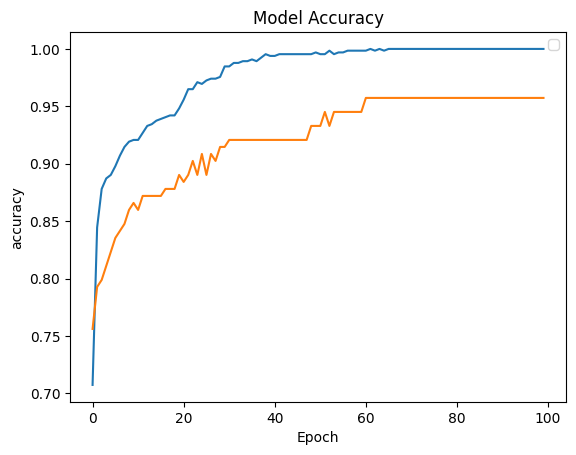

In [147]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend('Train', 'Validation')

plt.show()

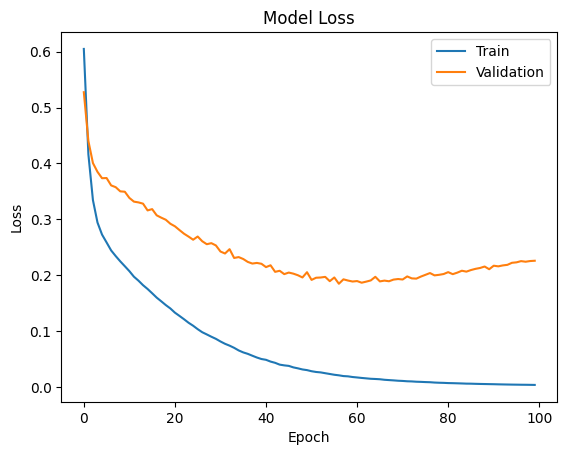

In [148]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [149]:
model.save('model_jst.h5')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


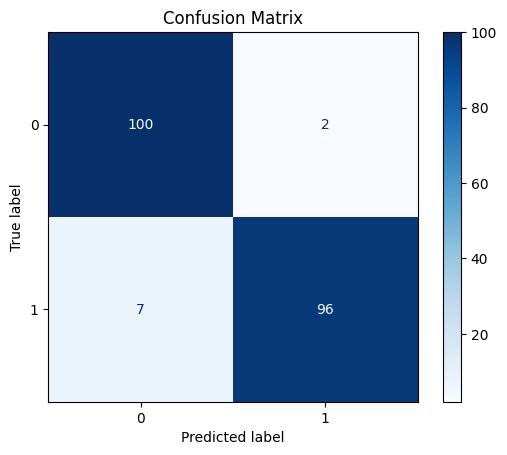

In [150]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [151]:
!ls

 gradio_app.py	 'heart (2).csv'   heart.csv	  sample_data
'heart (1).csv'  'heart (3).csv'   model_jst.h5   scaler.save


In [152]:
from google.colab import files
files.download('model_jst.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [153]:
import gradio as gr

In [154]:
import joblib
joblib.dump(scaler, 'scaler.save')

['scaler.save']

In [155]:
from google.colab import files
files.download('scaler.save')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [156]:
import numpy as np

def prediksi(age, sex, cp, trestbps, chol, fbs, restecg,
             thalach, exang, oldpeak, slope, ca, thal):

  # Jenis Kelamin
  if sex == "Laki-laki":
    sex = 1
  else:
    sex = 0

  # Tipe Dada
  cp_dict = {
      "Typical Angina": 0,
      "Atypical Angina": 1,
      "Non-Anginal Pain": 2,
      "Asymptomatic": 3
  }
  cp = cp_dict[cp]

  # Gula Darah
  if fbs == ">120 mg/dL":
    fbs = 1
  else:
    fbs = 0

  # Hasil Rekaman EKG
  restecg_dict = {
      "Normal": 0,
      "Kelainan ST-T": 1,
      "Left Ventricular Hypertrophy": 2
  }
  restecg = restecg_dict[restecg]

  # Angina
  if exang == "Ya":
    exang = 1
  else:
    exang = 0

  # Slope
  slope_dict = {
      "Upsloping": 0,
      "Flat": 1,
      "Downsloping": 2
  }
  slope = slope_dict[slope]

  # Nilai Thal
  thal_dict = {
      "Normal": 0,
      "Fixed Defect": 1,
      "Reversible Defect": 2
  }
  thal = thal_dict[thal]

  # Prediksi AI
  data = np.array([[age, sex, cp, trestbps, chol,
                    fbs, restecg, thalach, exang,
                    oldpeak, slope, ca, thal]])

  data = scaler.transform(data)

  hasil = model.predict(data)[0][0]

  if hasil > 0.5:
    return """
🤦‍♂️ Berpotensi Penyakit Jantung

Model AI kami Kelompok 4 mendeteksi adanya kemungkinan risiko penyakit jantung berdasarkan data yang dimasukkan.

Penyebabnya dapat dipengaruhi oleh beberapa faktor seperti tekanan darah tinggi, kadar kolesterol tinggi, kurangnya aktivitas fisik, serta gaya hidup yang kurang sehat.

Saran dari Kelompok 4:

• Konsultasikan dengan dokter untuk pemeriksaan lebih lanjut.
• Kurangi makanan tinggi lemak dan kolesterol.
• Rutin berolahraga dan jauhi kebiasaan merokok.
• Jaga pola tidur dan kelola stres dengan baik.

Dan ingat, ini adalah hasil prediksi AI dari Kelompok 4 😁🙌
"""

  else:
    return """
✅ Tidak Berpotensi Penyakit Jantung

Wah, Anda sehat wal-afiat. Pertahankan dengan cara:

• Pertahankan pola makan yang sehat.
• Tetap rutin berolahraga.
• Hindari rokok, baik sebagai perokok aktif maupun pasif.

Semoga selalu diberikan kesehatan.

Wassalam 😊
"""

# Description

In [157]:
import gradio as gr

demo = gr.Interface(
    fn=prediksi,

    inputs=[
        gr.Number(label="Umur"),

        gr.Dropdown(
            choices=["Perempuan", "Laki-laki"],
            label="Jenis Kelamin"
        ),

        gr.Dropdown(
            choices=[
                "Typical Angina",
                "Atypical Angina",
                "Non-Anginal Pain",
                "Asymptomatic"
            ],
            label="Tipe Dada"
        ),

        gr.Number(label="Tekanan Darah"),

        gr.Number(label="Kolesterol"),

        gr.Dropdown(
            choices=["≤120 mg/dL", ">120 mg/dL"],
            label="Gula Darah"
        ),

        gr.Dropdown(
            choices=[
                "Normal",
                "Kelainan ST-T",
                "Left Ventricular Hypertrophy"
            ],
            label="Hasil Rekaman EKG"
        ),

        gr.Number(label="Detak Jantung Maksimum"),

        gr.Dropdown(
            choices=["Tidak", "Ya"],
            label="Angina"
        ),

        gr.Number(label="Oldpeak"),

        gr.Dropdown(
            choices=[
                "Upsloping",
                "Flat",
                "Downsloping"
            ],
            label="Slope"
        ),

        gr.Number(label="Nilai CA"),

        gr.Dropdown(
            choices=[
                "Normal",
                "Fixed Defect",
                "Reversible Defect"
            ],
            label="Nilai Thal"
        )
    ],   # <--- koma penting di sini

    outputs="text",

    title="❤️ HeartCare AI Kelompok 4",

    description="""
Masukkan data pasien kemudian tekan Submit.

 Panduan Pengisian:

 Jenis Kelamin
• Perempuan
• Laki-laki

 Tipe Dada
• Typical Angina
• Atypical Angina
• Non-Anginal Pain
• Asymptomatic

 Gula Darah
• ≤120 mg/dL
• >120 mg/dL

 Hasil Rekaman EKG
• Normal
• Kelainan ST-T
• Left Ventricular Hypertrophy

 Angina
• Tidak
• Ya

 Slope
• Upsloping
• Flat
• Downsloping

🫀 Nilai Thal
• Normal
• Fixed Defect
• Reversible Defect

🤖 AI Kelompok 4 akan memprediksi apakah pasien berpotensi terkena penyakit jantung atau tidak.
"""
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14b7e8ca2defcba3ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [158]:
%%writefile gradio_app.py
import gradio as gr

demo = gr.Interface(
    fn=prediksi,
    inputs=[
        gr.Number(label="Umur"),
        gr.Number(label="Jenis Kelamin"),
        gr.Number(label="Tipe Dada"),
        gr.Number(label="Tekanan Darah"),
        gr.Number(label="Kolesterol"),
        gr.Number(label="Gula Darah"),
        gr.Number(label="Hasil Rekaman EKG"),
        gr.Number(label="Detak Jantung Maksimum"),
        gr.Number(label="Angina"),
        gr.Number(label="Oldpeak"),
        gr.Number(label="Slope"),
        gr.Number(label="Nilai CA"),
        gr.Number(label="Nilai Thal")
    ],
    outputs="text",
    title="MemPrediksi Penyakit Jantung Menggunakan JST",
    description="""Masukan Data Pasien Kemudian Pencet Summit.AI akan memPrediksi apakah pasien berpotensi terkena penyakit Jantung atau Tidak"""
)

demo.launch()

Overwriting gradio_app.py


In [159]:
from google.colab import files
files.download('gradio_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>